In [1]:
import os
os.chdir('../')
%pwd

'/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer'

In [2]:
import gc
import torch
gc.collect()
torch.mps.empty_cache()

In [9]:
from dataclasses import dataclass
from pathlib import Path


@dataclass(frozen=True)
class MultiQueryConfig:
    root_dir: Path
    dense_embd: Path
    local_data: Path
    out:Path
    anot:Path
    k:int

In [4]:
from src.task2 import logger
from src.task2.constants import *
from src.task2.utils.common import read_yaml, create_directories, load_json

In [10]:
class ConfigurationManager:
    def __init__(
        self,
        config_filepath = CONFIG_FILE_PATH,
        params_filepath = PARAMS_FILE_PATH):

        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)

        create_directories([self.config.artifacts_root])


    
    def get_mq_config(self) -> MultiQueryConfig:
        config = self.config.mqr

        create_directories([config.root_dir])

        mq_config = MultiQueryConfig(
            root_dir=Path(config.root_dir),
            dense_embd=Path(config.Dense_embedding),
            local_data=Path(config.local_data_file),
            out=Path(config.OUTPUT),
            anot=Path(config.annot),
            k=int(self.params.mul_k)
            
        )

        return mq_config

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
import torch

In [11]:

class MultiQueryRetrieval:
    def __init__(self, config: MultiQueryConfig):
        self.config=config
        master_annotations = load_json(self.config.anot)
        self.label_1=input("Provide Dataset 1 Label name (e.g: Liver chunk 0):")
        embed1= input("Dense Embeddings 1| What is the name of file? (e.g., dense.pt): ")
        logger.info(f"{embed1}.... Loaded")
        emfile1=os.path.join(self.config.dense_embd,embed1)
        self.emb1 = torch.load(emfile1).numpy()
        localfile1= input("Local File Input 1| What is the name of file? (e.g., liver.npy): ")
        logger.info(f"{localfile1}.... Loaded")
        lf1=os.path.join(self.config.local_data,localfile1)
        self.raw1 = np.load(lf1)
        box_1=input('Enter Dataset 1 annotation name (e.g., ls0, ls1, hs1, hs0, ps1): ')
        self.mito_boxes_ds1 = master_annotations[box_1]

        self.label_2=input("Provide Dataset 2 label name|(e.g: pancreas chunk 0):")
        embed2= input("Dense Embeddings 2| What is the name of file? (e.g., dense.pt): ")
        logger.info(f"{embed2}.... Loaded")
        emfile2=os.path.join(self.config.dense_embd,embed2)
        self.emb2 = torch.load(emfile2).numpy()
        localfile2= input("Local File Input 2| What is the name of file? (e.g., liver.npy): ")
        logger.info(f"{localfile2}.... Loaded")
        lf2=os.path.join(self.config.local_data,localfile2)
        self.raw2 = np.load(lf2)
        box_2=input('Enter Dataset 2 annotation name (e.g., ls0, ls1, hs1, hs0, ps1): ')
        self.mito_boxes_ds2 = master_annotations[box_2]

        self.c1, self.z1, self.h1, self.w1 = self.emb1.shape
        self.c2, self.z2, self.h2, self.w2 = self.emb2.shape

        self.flat1 = normalize(self.emb1.reshape(self.c1, -1).T, norm='l2')
        self.flat2 = normalize(self.emb2.reshape(self.c2, -1).T, norm='l2')

        logger.info(
            f'[{self.label_1}] embeddings: {self.emb1.shape} | voxels: {self.flat1.shape}\n'
            f'[{self.label_2}] embeddings: {self.emb2.shape} | voxels: {self.flat2.shape}\n'
        )

    def _align(self, query_vec, source=1):
        flat_src = self.flat1 if source == 1 else self.flat2
        flat_tgt = self.flat2 if source == 1 else self.flat1
        mu1  = flat_src.mean(axis=0, keepdims=True)
        std1 = flat_src.std(axis=0,  keepdims=True) + 1e-8
        mu2  = flat_tgt.mean(axis=0, keepdims=True)
        std2 = flat_tgt.std(axis=0,  keepdims=True) + 1e-8

        q_aligned = normalize((query_vec - mu1) / std1, norm='l2')
        g_aligned = normalize((flat_tgt  - mu2) / std2, norm='l2')

        return q_aligned, g_aligned
    
    def _roi_vec(self,dataset, z, y_min, y_max, x_min, x_max):
        emb = self.emb1 if dataset == 1 else self.emb2
        roi = emb[:, z, y_min:y_max, x_min:x_max]
        vec = roi.mean(axis=(1, 2))
        vec = vec / (np.linalg.norm(vec) + 1e-8)
        return vec.reshape(1, -1)
    
    def _build_vecs(self, dataset, boxes):
        return np.vstack([
            self._roi_vec(dataset, b['z'], b['y_min'], b['y_max'],
                          b['x_min'], b['x_max'])
            for b in boxes
        ])
    
    def mean_aggregation(self, boxes, use_alignment=True):
        vecs = self._build_vecs(1, boxes)                   
        q    = normalize(vecs.mean(axis=0, keepdims=True), norm='l2')
        if use_alignment:
            q, gallery = self._align(q)
        else:
            gallery = self.flat2
        sim = (gallery @ q.T).squeeze()
        return sim.reshape(self.z2, self.h2, self.w2)
    
    def score_fusion(self, boxes, use_alignment=True):
        fused = np.zeros((self.z2 * self.h2 * self.w2,), dtype=np.float32)
        for b in boxes:
            q = self._roi_vec(1, b['z'], b['y_min'], b['y_max'],
                              b['x_min'], b['x_max'])
            if use_alignment:
                q, gallery = self._align(q)
            else:
                gallery = self.flat2
            fused += (gallery @ q.T).squeeze()
        return (fused / len(boxes)).reshape(self.z2, self.h2, self.w2)
    
    def reciprocal_rank_fusion(self, boxes, use_alignment=True, k_rrf=60,top_n=100000):
        N2  = self.z2 * self.h2 * self.w2
        rrf = np.zeros(N2, dtype=np.float64)
        for b in boxes:
            q = self._roi_vec(1, b['z'], b['y_min'], b['y_max'],
                              b['x_min'], b['x_max'])
            if use_alignment:
                q, gallery = self._align(q,source=1)
            else:
                gallery = self.flat2
            sim      = (gallery @ q.T).squeeze()
            top_indices = np.argpartition(-sim, top_n)[:top_n]
            sorted_top_indices = top_indices[np.argsort(-sim[top_indices])]
            for rank, idx in enumerate(sorted_top_indices):
                rrf[idx] += 1.0 / (rank + k_rrf)
        return rrf.reshape(self.z2, self.h2, self.w2)
    
    def per_query_heatmaps(self, boxes, use_alignment=True):
        maps = []
        for b in boxes:
            q = self._roi_vec(1, b['z'], b['y_min'], b['y_max'],
                              b['x_min'], b['x_max'])
            if use_alignment:
                q, gallery = self._align(q)
            else:
                gallery = self.flat2
            sim = (gallery @ q.T).squeeze()
            maps.append(sim.reshape(self.z2, self.h2, self.w2))
        return maps
    
    def precision_at_k(self, heatmap, gt_boxes_2,k:int = 15000):
        gt = np.zeros((self.z2, self.h2, self.w2), dtype=bool)
        for b in gt_boxes_2:
            gt[b['z'], b['y_min']:b['y_max'], b['x_min']:b['x_max']] = True
        flat_sim = heatmap.flatten()
        flat_gt  = gt.flatten()
        top_k    = np.argsort(-flat_sim)[:k]

        tp       = flat_gt[top_k].sum()
        total    = flat_gt.sum()
        p        = tp / k
        r        = tp / (total + 1e-8)
        f1       = 2 * p * r / (p + r + 1e-8)
        if tp == 0:
            logger.info(f"DEBUG: No matches found in top {k} pixels.")
            logger.info(f"Max similarity in heatmap: {flat_sim.max():.4f}")
            logger.info(f"Total positive pixels in Ground Truth: {total}")
        return {'precision@k': round(p, 4), 'recall@k': round(r, 4),
                'f1@k': round(f1, 4), 'k': k, 'total_pos': int(total)}

    def compare_methods_quantitative(self,
                                      use_alignment=True):
        boxes= self.mito_boxes_ds1
        k=self.config.k
        gt_boxes_2 =self.mito_boxes_ds2
        results = {}
        for name, hmap in [
            ('mean_agg',    self.mean_aggregation(boxes, use_alignment)),
            ('score_fusion',self.score_fusion(boxes, use_alignment)),
            ('rrf',         self.reciprocal_rank_fusion(boxes, use_alignment)),
        ]:
            results[name] = self.precision_at_k(hmap, gt_boxes_2, k)

        logger.info(f'{"Method":<16} {"P@k":>8} {"R@k":>8} {"F1@k":>8}')
        logger.info('─' * 42)
        for name, m in results.items():
            logger.info(f'{name:<16} {m["precision@k"]:>8.4f} '
                  f'{m["recall@k"]:>8.4f} {m["f1@k"]:>8.4f}')
        return results
    
    

    def plot_multi_query(
        self,
        use_alignment=True,
    ):
        boxes=self.mito_boxes_ds1
        COLORS = ['#4ade80', '#f472b6', '#facc15', '#60a5fa', '#fb923c']

        hmap_mean  = self.mean_aggregation(boxes, use_alignment)
        hmap_score = self.score_fusion(boxes, use_alignment)
        hmap_rrf   = self.reciprocal_rank_fusion(boxes, use_alignment)
        indiv_maps = self.per_query_heatmaps(boxes, use_alignment)

        threshold=float(input("Input threshold to only highlight the Top '%' of matches:"))
        z_slice_2 = int(input('Input which slide need to use or ROI (0,1,2) :'))

        s_mean  = hmap_mean[z_slice_2]
        s_score = hmap_score[z_slice_2]
        s_rrf   = hmap_rrf[z_slice_2]
        rrf_n   = (s_rrf - s_rrf.min()) / (s_rrf.max() - s_rrf.min() + 1e-8)

        n_indiv  = len(boxes)
        n_cols_top = n_indiv + 2          # query source + DS2 raw + per-query maps
        n_cols_bot = 4                    # mean | score fusion | rrf | histograms

        fig = plt.figure(figsize=(max(20, n_cols_top * 3.5), 13))
        fig.patch.set_facecolor('#0e1410')

        outer = gridspec.GridSpec(2, 1, figure=fig,
                                  hspace=0.35, top=0.93, bottom=0.04,
                                  left=0.03, right=0.97)
        top   = gridspec.GridSpecFromSubplotSpec(
            1, n_cols_top, subplot_spec=outer[0], wspace=0.08
        )
        bot   = gridspec.GridSpecFromSubplotSpec(
            1, n_cols_bot, subplot_spec=outer[1], wspace=0.10
        )

        # ── Top row ────────────────────────────────────────────────────────────

        # DS1 with all query boxes
        ax_src = fig.add_subplot(top[0])
        ax_src.imshow(self.raw1[boxes[0]['z']], cmap='gray')
        for ci, b in enumerate(boxes):
            ax_src.add_patch(mpatches.Rectangle(
                (b['x_min'], b['y_min']),
                b['x_max'] - b['x_min'], b['y_max'] - b['y_min'],
                linewidth=1.8, edgecolor=COLORS[ci % len(COLORS)],
                facecolor='none',
            ))
            ax_src.text(b['x_min'], b['y_min'] - 5, f'Q{ci}',
                        color=COLORS[ci % len(COLORS)], fontsize=7)
        ax_src.set_title(f'{self.label_1} — {len(boxes)} queries',
                         color='#4ade80', fontsize=9, pad=5)
        ax_src.axis('off')

        # DS2 raw
        ax_tgt = fig.add_subplot(top[1])
        ax_tgt.imshow(self.raw2[z_slice_2], cmap='gray')
        ax_tgt.set_title(f'{self.label_2}  z={z_slice_2}',
                         color='#e8f5ec', fontsize=9, pad=5)
        ax_tgt.axis('off')

        # Individual per-query heatmaps
        for qi, imap in enumerate(indiv_maps):
            ax = fig.add_subplot(top[qi + 2])
            ax.imshow(self.raw2[z_slice_2], cmap='gray')
            sl     = imap[z_slice_2]
            masked = np.ma.masked_where(sl < threshold, sl)
            ax.imshow(masked, cmap='viridis', alpha=0.65,
                      vmin=threshold, vmax=sl.max() + 1e-6)
            ax.set_title(f'Q{qi}  sim={sl.max():.2f}',
                         color=COLORS[qi % len(COLORS)], fontsize=9, pad=5)
            ax.axis('off')

        # ── Bottom row ─────────────────────────────────────────────────────────

        methods_bot = [
            (s_mean,  threshold, 'hot',    'Mean aggregation'),
            (s_score, threshold, 'magma',    'Score fusion'),
            (rrf_n,   0.5,       'plasma', 'RRF (normalised)'),
        ]
        for ci, (hmap, thr, cmap, title) in enumerate(methods_bot):
            ax = fig.add_subplot(bot[ci])
            ax.imshow(self.raw2[z_slice_2], cmap='gray')
            masked = np.ma.masked_where(hmap < thr, hmap)
            im = ax.imshow(masked, cmap=cmap, alpha=0.65,
                           vmin=thr, vmax=hmap.max() + 1e-6)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Score')
            ax.set_title(title, color='#e8f5ec', fontsize=9, pad=5)
            ax.axis('off')

        # Histogram panel
        ax_h = fig.add_subplot(bot[3])
        ax_h.set_facecolor('#141c16')
        ax_h.hist(s_mean.flatten(),  bins=50, alpha=0.55,
                  color='#1D9E75', label='Mean agg',     linewidth=0)
        ax_h.hist(s_score.flatten(), bins=50, alpha=0.55,
                  color='#D85A30', label='Score fusion', linewidth=0)
        ax_h.hist(rrf_n.flatten(),   bins=50, alpha=0.55,
                  color='#7F77DD', label='RRF',          linewidth=0)
        ax_h.axvline(threshold, color='white', linewidth=1.2,
                     linestyle='--', label=f'thr={threshold}')
        ax_h.set_xlabel('Score', color='#6b8f72', fontsize=9)
        ax_h.set_ylabel('Count', color='#6b8f72', fontsize=9)
        ax_h.tick_params(colors='#6b8f72', labelsize=8)
        for sp in ax_h.spines.values():
            sp.set_edgecolor('#1D9E75')
        ax_h.legend(fontsize=7, labelcolor='#e8f5ec',
                    facecolor='#0e1410', edgecolor='#1D9E75')
        ax_h.set_title('Score distributions', color='#e8f5ec',
                        fontsize=9, pad=5)

        fig.suptitle(
            f'Multi-query retrieval — {len(boxes)} queries  |  '
            f'{self.label_1} → {self.label_2}',
            color='#e8f5ec', fontsize=12, fontweight='bold',
        )
        save_name=input("Enter file save name(e.g Liver.png): ")
        save_path=os.path.join(self.config.out,"multiquery_viz",save_name)
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight',
                        facecolor=fig.get_facecolor())
            logger.info(f'Saved → {save_path}')
        plt.show()
        plt.close('all')  # Explicitly kill the figure object
        del fig         # Remove it from Python's memory
        import gc
        gc.collect()

    # ── PCA with multi-query stars ─────────────────────────────────────────────

    def plot_pca_multi_query(
        self,n_background=1500,
        use_alignment=True,
    ):
        boxes_1=self.mito_boxes_ds1
        boxes_2=self.mito_boxes_ds2
        idx1 = np.random.choice(len(self.flat1), n_background, replace=False)
        idx2 = np.random.choice(len(self.flat2), n_background, replace=False)
        bg1  = self.flat1[idx1]
        bg2  = self.flat2[idx2]

        vecs1 = self._build_vecs(1, boxes_1)
        vecs2 = self._build_vecs(2, boxes_2)

        if use_alignment:
            mu1  = self.flat1.mean(0); std1 = self.flat1.std(0) + 1e-8
            mu2  = self.flat2.mean(0); std2 = self.flat2.std(0) + 1e-8
            bg1   = normalize((bg1   - mu1) / std1, norm='l2')
            bg2   = normalize((bg2   - mu2) / std2, norm='l2')
            vecs1 = normalize((vecs1 - mu1) / std1, norm='l2')
            vecs2 = normalize((vecs2 - mu2) / std2, norm='l2')

        all_vecs = np.vstack([bg1, bg2, vecs1, vecs2])
        pca      = PCA(n_components=2)
        proj     = pca.fit_transform(all_vecs)
        var      = pca.explained_variance_ratio_

        n1 = len(bg1); n2 = len(bg2)
        n_v1 = len(vecs1); n_v2 = len(vecs2)
        p_bg1  = proj[:n1]
        p_bg2  = proj[n1:n1+n2]
        p_v1   = proj[n1+n2:n1+n2+n_v1]
        p_v2   = proj[n1+n2+n_v1:]

        COLORS = ['#4ade80', '#f472b6', '#facc15', '#60a5fa', '#fb923c']

        fig, ax = plt.subplots(figsize=(10, 8))
        fig.patch.set_facecolor('#0e1410')
        ax.set_facecolor('#0e1410')

        ax.scatter(p_bg1[:,0], p_bg1[:,1], c='#185FA5',
                   alpha=0.2, s=4, label=self.label_1)
        ax.scatter(p_bg2[:,0], p_bg2[:,1], c='#D85A30',
                   alpha=0.2, s=4, label=self.label_2)

        # Draw each query as a distinctly coloured star
        for qi, (v1, v2) in enumerate(zip(p_v1, p_v2)):
            c = COLORS[qi % len(COLORS)]
            ax.scatter(*v1, c=c, s=120, marker='*', zorder=6)
            ax.scatter(*v2, c=c, s=120, marker='P', zorder=6)
            ax.plot([v1[0], v2[0]], [v1[1], v2[1]],
                    color=c, alpha=0.4, linewidth=1, linestyle='--')
            ax.annotate(f'Q{qi}', v1, fontsize=7,
                        color=c, textcoords='offset points', xytext=(4, 4))

        # Convex hull of all query stars to show mito region
        from scipy.spatial import ConvexHull
        all_stars = np.vstack([p_v1, p_v2])
        if len(all_stars) >= 3:
            hull = ConvexHull(all_stars)
            for simplex in hull.simplices:
                ax.plot(all_stars[simplex, 0], all_stars[simplex, 1],
                        'w-', alpha=0.15, linewidth=0.8)

        # Legend: star = DS1, plus = DS2
        ax.scatter([], [], marker='*', c='white', s=80, label='DS1 query mito')
        ax.scatter([], [], marker='P', c='white', s=80, label='DS2 query mito')

        ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% var)',
                      color='#6b8f72', fontsize=9)
        ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% var)',
                      color='#6b8f72', fontsize=9)
        ax.set_title(
            f'PCA — multi-query embedding space\n'
            f'{self.label_1} vs {self.label_2}  |  '
            f'{len(boxes_1)} queries each',
            color='#e8f5ec', fontsize=11, pad=8,
        )
        ax.tick_params(colors='#6b8f72', labelsize=8)
        for sp in ax.spines.values():
            sp.set_edgecolor('#1D9E75')
        ax.legend(fontsize=8, facecolor='#141c16',
                  edgecolor='#1D9E75', labelcolor='#e8f5ec')
        save_name=input("Enter file save name(e.g Liver.png): ")
        save_path=os.path.join(self.config.out,"multiquery_viz",save_name)
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight',
                        facecolor=fig.get_facecolor())
            logger.info(f'Saved → {save_path}')
        plt.show()
        plt.close('all')  # Explicitly kill the figure object
        del fig         # Remove it from Python's memory
        gc.collect()

[2026-04-06 20:48:04,275: INFO: common: yaml file: config/config.yaml loaded successfully]
[2026-04-06 20:48:04,277: INFO: common: yaml file: params.yaml loaded successfully]
[2026-04-06 20:48:04,278: INFO: common: created directory at: artifacts]
[2026-04-06 20:48:04,279: INFO: common: created directory at: artifacts/retri_viz]
[2026-04-06 20:48:04,280: INFO: common: json file loaded succesfully from: annotations.json]
[2026-04-06 20:48:21,552: INFO: 2785075611: ls0.pt.... Loaded]
[2026-04-06 20:48:28,347: INFO: 2785075611: ls0.npy.... Loaded]
[2026-04-06 20:48:56,818: INFO: 2785075611: ts0.pt.... Loaded]
[2026-04-06 20:49:04,631: INFO: 2785075611: ts0.npy.... Loaded]
[2026-04-06 20:49:21,946: INFO: 2785075611: [Liver chunk s0] embeddings: (384, 6, 448, 448) | voxels: (1204224, 384)
[Lipid Tcell s0] embeddings: (384, 6, 448, 448) | voxels: (1204224, 384)
]


/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia

[2026-04-06 20:51:39,383: INFO: 2785075611: Saved → OUTPUT/multiquery_viz/mq_neg.png]


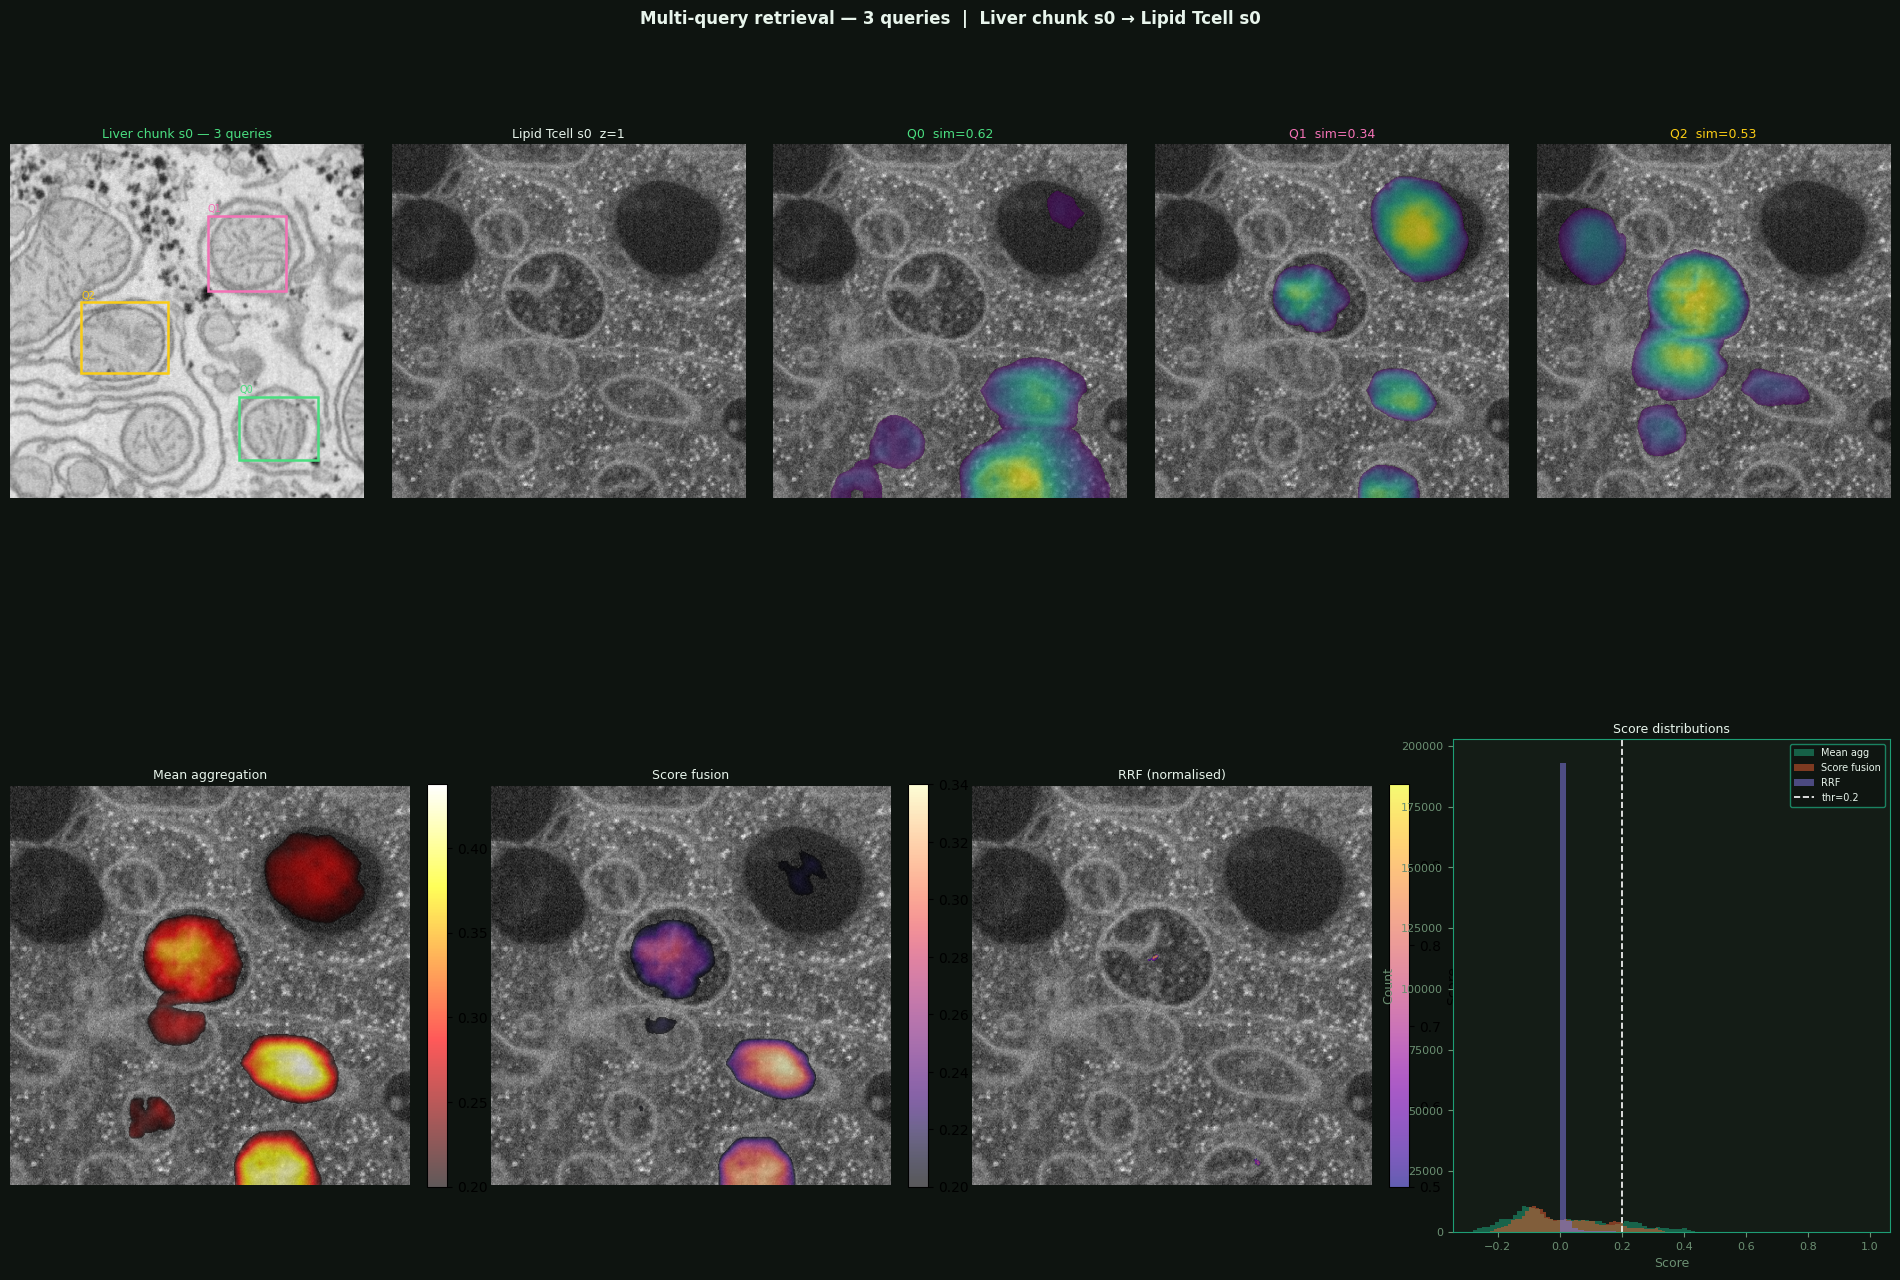

/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


[2026-04-06 20:52:44,669: INFO: 2785075611: Saved → OUTPUT/multiquery_viz/mqpcaneg.png]


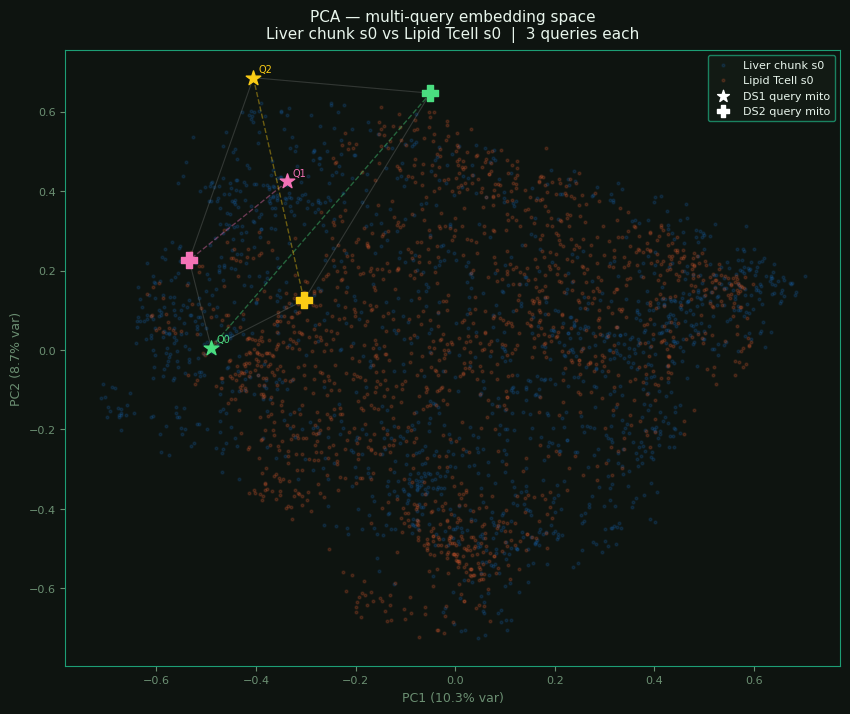

/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia

[2026-04-06 20:54:01,548: INFO: 2785075611: DEBUG: No matches found in top 20000 pixels.]
[2026-04-06 20:54:01,552: INFO: 2785075611: Max similarity in heatmap: 0.4663]
[2026-04-06 20:54:01,553: INFO: 2785075611: Total positive pixels in Ground Truth: 32400]
[2026-04-06 20:54:01,627: INFO: 2785075611: DEBUG: No matches found in top 20000 pixels.]
[2026-04-06 20:54:01,628: INFO: 2785075611: Max similarity in heatmap: 0.3634]
[2026-04-06 20:54:01,628: INFO: 2785075611: Total positive pixels in Ground Truth: 32400]
[2026-04-06 20:54:01,661: INFO: 2785075611: Method                P@k      R@k     F1@k]
[2026-04-06 20:54:01,662: INFO: 2785075611: ──────────────────────────────────────────]
[2026-04-06 20:54:01,662: INFO: 2785075611: mean_agg           0.0000   0.0000   0.0000]
[2026-04-06 20:54:01,663: INFO: 2785075611: score_fusion       0.0000   0.0000   0.0000]
[2026-04-06 20:54:01,663: INFO: 2785075611: rrf                0.0091   0.0056   0.0069]


In [14]:
try:
    config=ConfigurationManager()
    mq_config= config.get_mq_config()
    mqr=MultiQueryRetrieval(config=mq_config)
    mqr.plot_multi_query()
    mqr.plot_pca_multi_query()
    mqr.compare_methods_quantitative()
    
except Exception as e:
    raise e
